In [1]:
# import important libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv('loan_prediction.csv')
df = df.drop('Loan_ID', axis =1) # drop the unnecessary columns whcih is not relate to target
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [45]:
# look at the shape of data
df.shape

(614, 12)

In [46]:
# to check there is any null value in data set
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [48]:
# Fill the nan values with some function
for i in df.columns:
    if df[i].dtype == 'object':
        df[i] = df[i].fillna(df[i].mode()[0])
    else:
        df[i] = df[i].fillna(np.ceil(df[i].mean()))
        
    

In [49]:
# df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df.isnull().sum()


Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [50]:
# EDA Do the  yourself

In [64]:
# convert the object data type columns into numerical columns data type
# We want to get number of unique values of each object
object_cols = []
for i in df.columns:
    if df[i].dtype == 'object':
        object_cols.append(i)

In [65]:
object_cols

[]

In [66]:
df = pd.get_dummies(columns=object_cols, data= df, drop_first=True, dtype = int)
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,5849,0.0,147.0,360.0,1.0,1,0,0,0,0,0,0,0,1,1
1,4583,1508.0,128.0,360.0,1.0,1,1,1,0,0,0,0,0,0,0
2,3000,0.0,66.0,360.0,1.0,1,1,0,0,0,0,1,0,1,1
3,2583,2358.0,120.0,360.0,1.0,1,1,0,0,0,1,0,0,1,1
4,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,0,0,0,1,1


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ApplicantIncome          614 non-null    int64  
 1   CoapplicantIncome        614 non-null    float64
 2   LoanAmount               614 non-null    float64
 3   Loan_Amount_Term         614 non-null    float64
 4   Credit_History           614 non-null    float64
 5   Gender_Male              614 non-null    int64  
 6   Married_Yes              614 non-null    int64  
 7   Dependents_1             614 non-null    int64  
 8   Dependents_2             614 non-null    int64  
 9   Dependents_3+            614 non-null    int64  
 10  Education_Not Graduate   614 non-null    int64  
 11  Self_Employed_Yes        614 non-null    int64  
 12  Property_Area_Semiurban  614 non-null    int64  
 13  Property_Area_Urban      614 non-null    int64  
 14  Loan_Status_Y            6

In [68]:
df['Loan_Status_Y'].value_counts()

Loan_Status_Y
1    422
0    192
Name: count, dtype: int64

<Axes: >

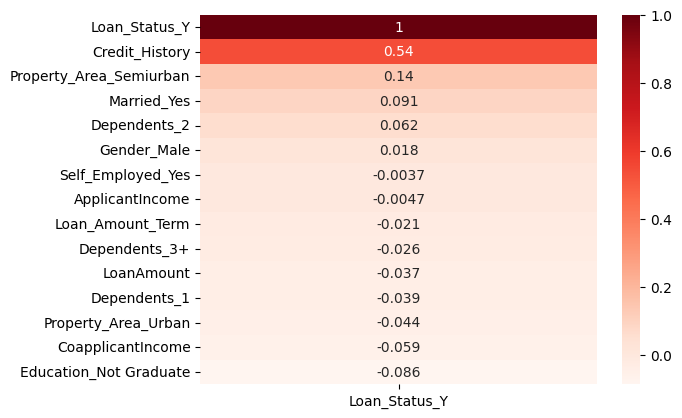

In [69]:
sns.heatmap(df.corr()[['Loan_Status_Y']].sort_values(by='Loan_Status_Y',
                                                     ascending = False),
           annot = True,cmap = 'Reds')

In [70]:
df2 = df.corr()[['Loan_Status_Y']].sort_values(by='Loan_Status_Y',
                                                     ascending = False).T
df2
fep = []
for i in df2.columns:
    if len(df2[df2[i]>0.03])>0:
        fep.append(i)
fep
fen = []
for i in df2.columns:
    if len(df2[df2[i]< - 0.03])>0:
        fen.append(i)
fen

['LoanAmount',
 'Dependents_1',
 'Property_Area_Urban',
 'CoapplicantIncome',
 'Education_Not Graduate']

In [71]:
print(fep, fen)

['Loan_Status_Y', 'Credit_History', 'Property_Area_Semiurban', 'Married_Yes', 'Dependents_2'] ['LoanAmount', 'Dependents_1', 'Property_Area_Urban', 'CoapplicantIncome', 'Education_Not Graduate']


In [72]:
for i in (df2[(df2['Loan_Status_Y']<(-0.03))].loc[:]):
    print(i)

Loan_Status_Y
Credit_History
Property_Area_Semiurban
Married_Yes
Dependents_2
Gender_Male
Self_Employed_Yes
ApplicantIncome
Loan_Amount_Term
Dependents_3+
LoanAmount
Dependents_1
Property_Area_Urban
CoapplicantIncome
Education_Not Graduate


In [73]:
# divide the data into dependent and indipendent
x = df.drop('Loan_Status_Y', axis = 1)
x.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,147.0,360.0,1.0,1,0,0,0,0,0,0,0,1
1,4583,1508.0,128.0,360.0,1.0,1,1,1,0,0,0,0,0,0
2,3000,0.0,66.0,360.0,1.0,1,1,0,0,0,0,1,0,1
3,2583,2358.0,120.0,360.0,1.0,1,1,0,0,0,1,0,0,1
4,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,0,0,0,1


In [74]:
y = df['Loan_Status_Y']
y.head()

0    1
1    0
2    1
3    1
4    1
Name: Loan_Status_Y, dtype: int64

In [75]:
# Standard Scale the data to scale data in one unit
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(x)

StandardScaler()

In [76]:
x_sc = sc.transform(x)
x_sc

array([[ 0.07299082, -0.55448733,  0.00674981, ..., -0.39260074,
        -0.7820157 ,  1.42814704],
       [-0.13441195, -0.03873155, -0.21952397, ..., -0.39260074,
        -0.7820157 , -0.70020801],
       [-0.39374734, -0.55448733, -0.95789103, ...,  2.54711697,
        -0.7820157 ,  1.42814704],
       ...,
       [ 0.43717437, -0.47240418,  1.2691193 , ..., -0.39260074,
        -0.7820157 ,  1.42814704],
       [ 0.35706382, -0.55448733,  0.48311565, ..., -0.39260074,
        -0.7820157 ,  1.42814704],
       [-0.13441195, -0.55448733, -0.15997824, ...,  2.54711697,
         1.2787467 , -0.70020801]], shape=(614, 14))

In [77]:
# now Split the data into trian and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_sc, y, train_size = 0.8, random_state= 15,
                                                   stratify=y)

In [78]:
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(491, 14) (123, 14)
(491,) (123,)


In [79]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt = DecisionTreeClassifier()#Calling the model without any parameter

In [25]:
dt.get_params() # default parameters

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [26]:
# train the model
dt.fit(x_train, y_train)


DecisionTreeClassifier()

In [27]:
dt.score(x_train, y_train) # it maybe an overfit case

1.0

In [28]:
y_pred = dt.predict(x_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1])

In [29]:
# Now do the evaluation of model
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
def model_evaluation(y_actual, y_prediction):
    print('Accuracy_Score = ',accuracy_score(y_actual, y_prediction))
    print('Confusion Matrix \n',confusion_matrix(y_actual, y_prediction))
    sns.heatmap(confusion_matrix(y_actual, y_prediction), annot = True, fmt = '.2f')
    print('Classification_Report \n',classification_report(y_actual, y_prediction))

Accuracy_Score =  0.7398373983739838
Confusion Matrix 
 [[22 16]
 [16 69]]
Classification_Report 
               precision    recall  f1-score   support

           0       0.58      0.58      0.58        38
           1       0.81      0.81      0.81        85

    accuracy                           0.74       123
   macro avg       0.70      0.70      0.70       123
weighted avg       0.74      0.74      0.74       123



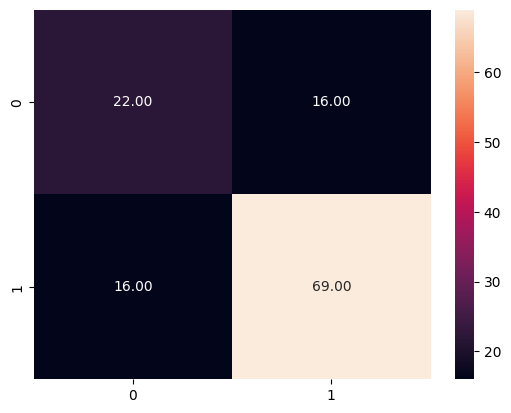

In [30]:
model_evaluation(y_test, y_pred)

In [31]:
dt.get_depth()

19

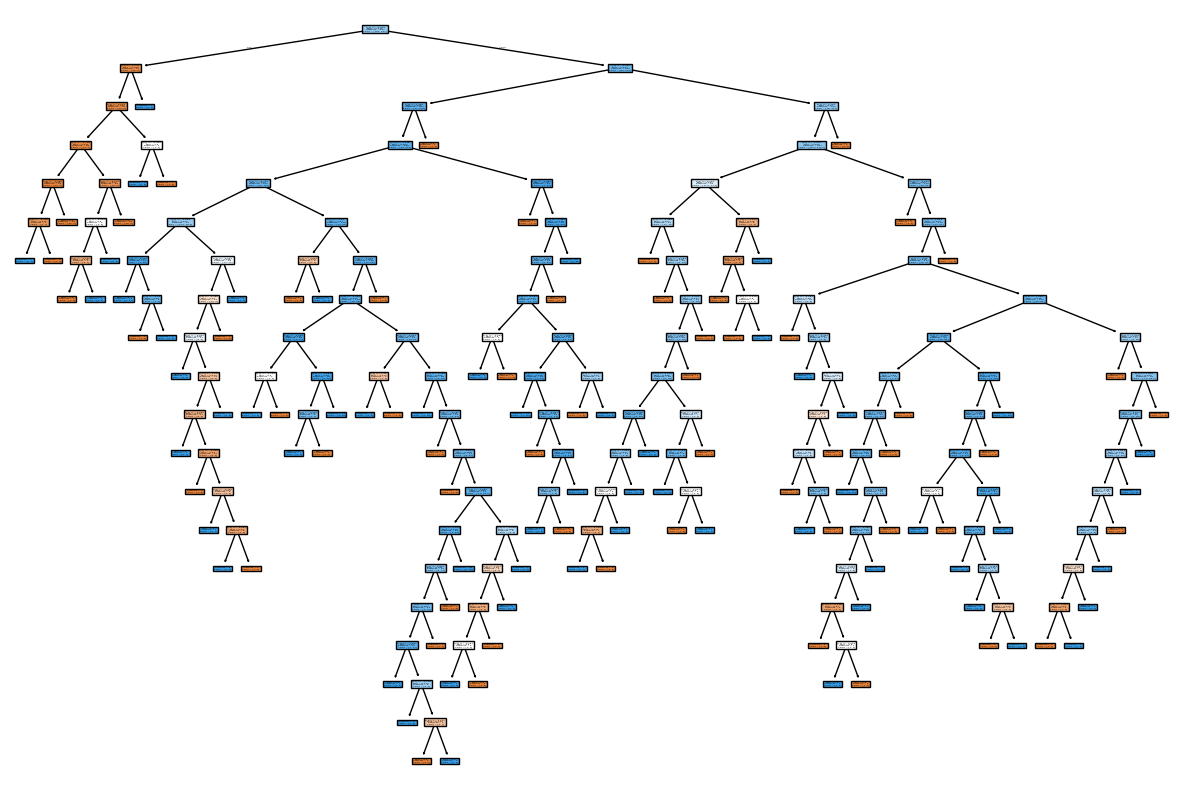

In [32]:
plt.figure(figsize=(15,10))
plot_tree(dt,filled=True)
plt.savefig('dt')
plt.show()

# Since over model is overfit on training data so we will do hyperparameter tuning


In [33]:
param_grid_dt={'criterion':['gini','entropy'],'max_depth':np.arange(3,20)}
new_dt = DecisionTreeClassifier()

In [34]:
# import GridSearchCV
from sklearn.model_selection import GridSearchCV


In [35]:
new_dt = GridSearchCV(new_dt, param_grid= param_grid_dt, refit=True, verbose = 3)

In [36]:
new_dt.fit(x_train,y_train)

Fitting 5 folds for each of 34 candidates, totalling 170 fits
[CV 1/5] END .......criterion=gini, max_depth=3;, score=0.778 total time=   0.0s
[CV 2/5] END .......criterion=gini, max_depth=3;, score=0.806 total time=   0.0s
[CV 3/5] END .......criterion=gini, max_depth=3;, score=0.806 total time=   0.0s
[CV 4/5] END .......criterion=gini, max_depth=3;, score=0.796 total time=   0.0s
[CV 5/5] END .......criterion=gini, max_depth=3;, score=0.796 total time=   0.0s
[CV 1/5] END .......criterion=gini, max_depth=4;, score=0.768 total time=   0.0s
[CV 2/5] END .......criterion=gini, max_depth=4;, score=0.806 total time=   0.0s
[CV 3/5] END .......criterion=gini, max_depth=4;, score=0.724 total time=   0.0s
[CV 4/5] END .......criterion=gini, max_depth=4;, score=0.786 total time=   0.0s
[CV 5/5] END .......criterion=gini, max_depth=4;, score=0.796 total time=   0.0s
[CV 1/5] END .......criterion=gini, max_depth=5;, score=0.778 total time=   0.0s
[CV 2/5] END .......criterion=gini, max_depth=5

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])},
             verbose=3)

In [37]:
print('Best Parameters = ',new_dt.best_params_)
print('Best Accuracy = ',new_dt.best_score_)

Best Parameters =  {'criterion': 'entropy', 'max_depth': np.int64(3)}
Best Accuracy =  0.7984126984126985


In [38]:
best_dt = DecisionTreeClassifier(criterion='entropy', max_depth = 3)
best_dt.fit(x_train, y_train)
best_dt.score(x_train, y_train)

0.814663951120163

In [39]:
best_y_pred = best_dt.predict(x_test)

Accuracy_Score =  0.8211382113821138
Confusion Matrix 
 [[17 21]
 [ 1 84]]
Classification_Report 
               precision    recall  f1-score   support

           0       0.94      0.45      0.61        38
           1       0.80      0.99      0.88        85

    accuracy                           0.82       123
   macro avg       0.87      0.72      0.75       123
weighted avg       0.84      0.82      0.80       123



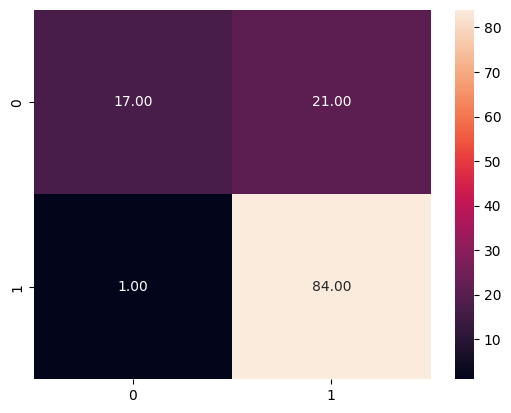

In [40]:
model_evaluation(y_test, best_y_pred)

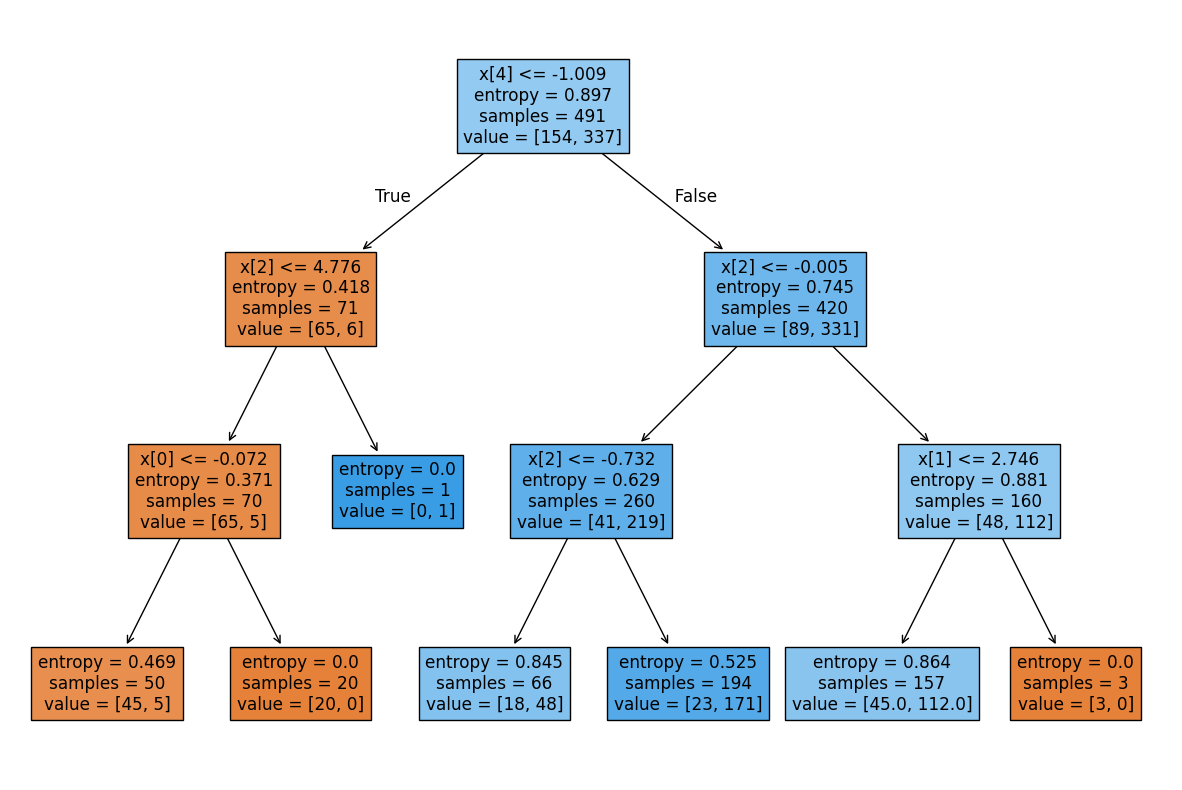

In [41]:
plt.figure(figsize=(15,10))
plot_tree(best_dt,filled=True)
plt.savefig('best_dt')
plt.show()

In [42]:
best_dt.get_depth()

3

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,147.0,360.0,1.0,1,0,0,0,0,0,0,0,1
1,4583,1508.0,128.0,360.0,1.0,1,1,1,0,0,0,0,0,0
2,3000,0.0,66.0,360.0,1.0,1,1,0,0,0,0,1,0,1
3,2583,2358.0,120.0,360.0,1.0,1,1,0,0,0,1,0,0,1
4,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0,0,0,0,0,0,0,0,0,0
610,4106,0.0,40.0,180.0,1.0,1,1,0,0,1,0,0,0,0
611,8072,240.0,253.0,360.0,1.0,1,1,1,0,0,0,0,0,1
612,7583,0.0,187.0,360.0,1.0,1,1,0,1,0,0,0,0,1
